# GRU

# yelp

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5408, Val Acc: 0.6375, Test Acc: 0.6508
Epoch 2, Train Acc: 0.6379, Val Acc: 0.6739, Test Acc: 0.6878
Epoch 3, Train Acc: 0.6823, Val Acc: 0.6694, Test Acc: 0.6819
Epoch 4, Train Acc: 0.7146, Val Acc: 0.6842, Test Acc: 0.7103
Epoch 5, Train Acc: 0.7520, Val Acc: 0.6922, Test Acc: 0.6975
Epoch 6, Train Acc: 0.7935, Val Acc: 0.6767, Test Acc: 0.6972
Epoch 7, Train Acc: 0.8223, Val Acc: 0.6908, Test Acc: 0.7006
Epoch 8, Train Acc: 0.8463, Val Acc: 0.6778, Test Acc: 0.6911
Epoch 9, Train Acc: 0.8660, Val Acc: 0.6597, Test Acc: 0.6883
Epoch 10, Train Acc: 0.8860, Val Acc: 0.6664, Test Acc: 0.6850
Epoch 11, Train Acc: 0.9077, Val Acc: 0.6600, Test Acc: 0.6783
Epoch 12, Train Acc: 0.9224, Val Acc: 0.6572, Test Acc: 0.6750
Epoch 13, Train Acc: 0.9333, Val Acc: 0.6656, Test Acc: 0.6853
Epoch 14, Train Acc: 0.9415, Val Acc: 0.6633, Test Acc: 0.6811
Epoch 15, Train Acc: 0.9511, Val Acc: 0.6500, Test Acc: 0.6711
Epoch 16, Train Acc: 0.9624, Val Acc: 0.6508, Test Acc: 0.6661
E

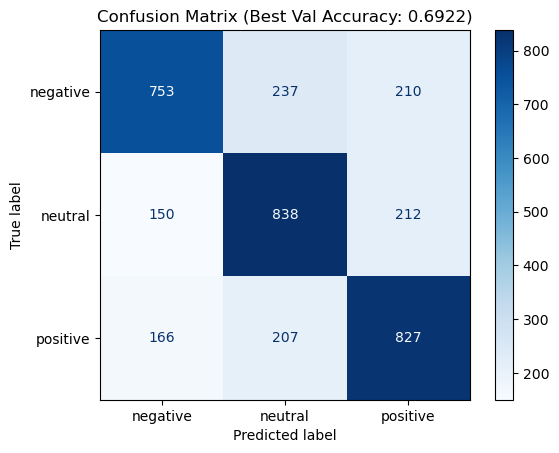

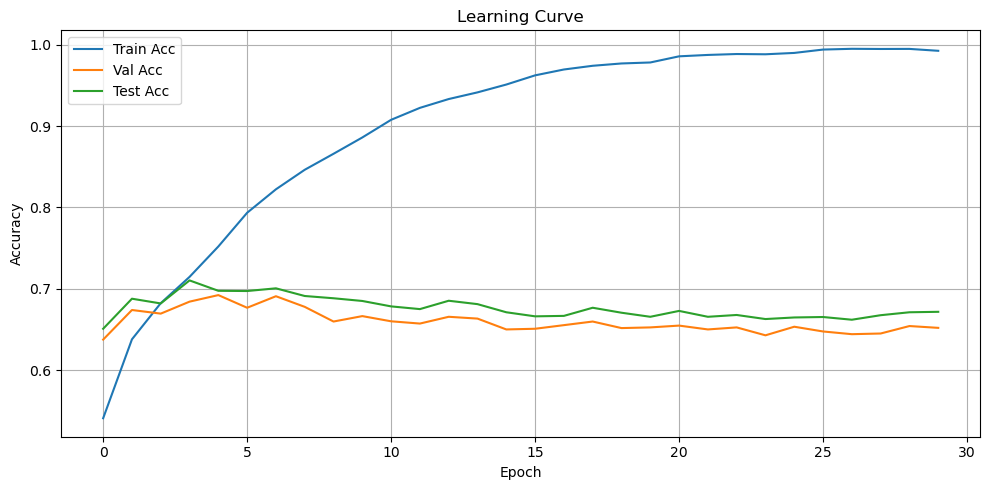

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocab -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Prepare Dataset -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.lengths = [min(len(t), 150) for t in texts]
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx], self.lengths[idx]

def collate_fn(batch):
    texts, labels, lengths = zip(*batch)
    return torch.stack(texts), torch.tensor(labels, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=128, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=128, collate_fn=collate_fn)

# ------------------- GRU Model (No Dropout) -------------------
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True
        self.gru = nn.GRU(embed_size, hidden_dim, n_layers, batch_first=True, bidirectional=bidirectional)
        self.norm = nn.LayerNorm(hidden_dim * 2 if bidirectional else hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        if self.gru.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.norm(hidden)
        return self.fc(hidden)

# ------------------- Train -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = GRUClassifier(len(vocab)+1, 300, hidden_dim=512, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.8)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for x, y, l in train_loader:
            x, y, l = x.to(device), y.to(device), l.to(device)
            optimizer.zero_grad()
            output = model(x, l)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            pred = torch.argmax(output, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for x, y, l in val_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y, l in test_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                test_correct += (pred == y).sum().item()
                test_total += y.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)
        scheduler.step()

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# dynabench

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.4783, Val Acc: 0.5236, Test Acc: 0.5389
Epoch 2, Train Acc: 0.6699, Val Acc: 0.5694, Test Acc: 0.6028
Epoch 3, Train Acc: 0.7119, Val Acc: 0.5583, Test Acc: 0.6139
Epoch 4, Train Acc: 0.7480, Val Acc: 0.5514, Test Acc: 0.5917
Epoch 5, Train Acc: 0.7797, Val Acc: 0.5569, Test Acc: 0.5972
Epoch 6, Train Acc: 0.8185, Val Acc: 0.5708, Test Acc: 0.6167
Epoch 7, Train Acc: 0.8415, Val Acc: 0.5806, Test Acc: 0.6097
Epoch 8, Train Acc: 0.8657, Val Acc: 0.5792, Test Acc: 0.6167
Epoch 9, Train Acc: 0.8998, Val Acc: 0.5514, Test Acc: 0.6278
Epoch 10, Train Acc: 0.9210, Val Acc: 0.5556, Test Acc: 0.6222
Epoch 11, Train Acc: 0.9402, Val Acc: 0.5514, Test Acc: 0.6208
Epoch 12, Train Acc: 0.9559, Val Acc: 0.5417, Test Acc: 0.5708
Epoch 13, Train Acc: 0.9632, Val Acc: 0.5514, Test Acc: 0.5958
Epoch 14, Train Acc: 0.9726, Val Acc: 0.5361, Test Acc: 0.5764
Epoch 15, Train Acc: 0.9600, Val Acc: 0.5611, Test Acc: 0.6083
Epoch 16, Train Acc: 0.9845, Val Acc: 0.5444, Test Acc: 0.5931
E

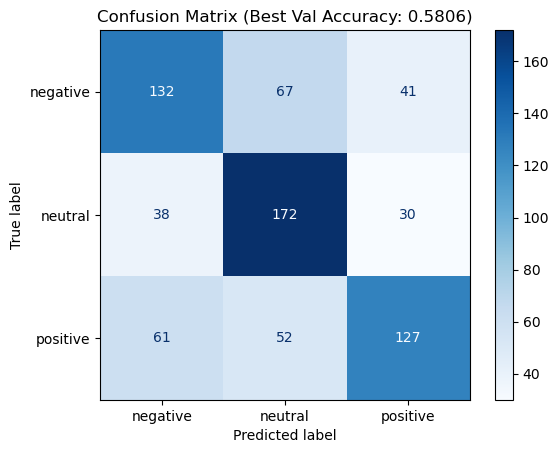

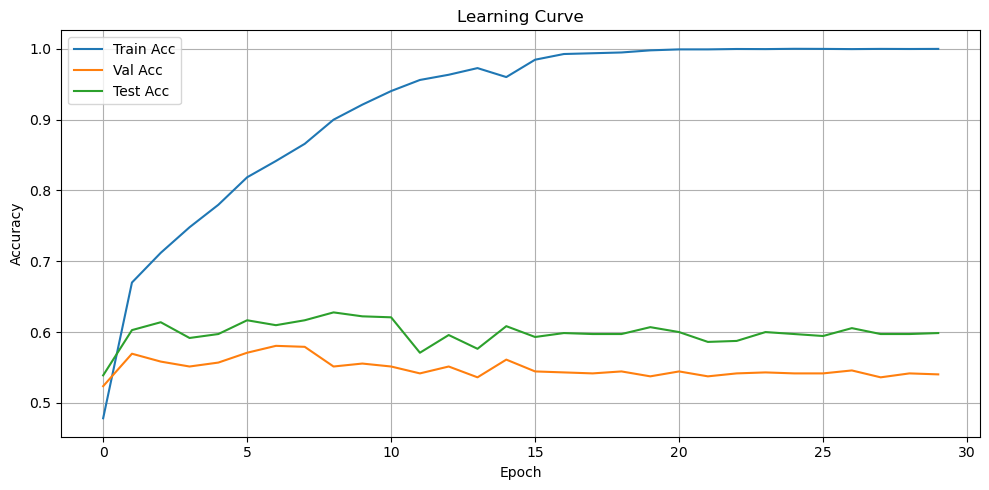

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "/Users/tejamallireddy/Downloads/dynabench/train.csv"
val_file = "/Users/tejamallireddy/Downloads/dynabench/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/dynabench/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocab -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Prepare Dataset -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.lengths = [min(len(t), 150) for t in texts]
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx], self.lengths[idx]

def collate_fn(batch):
    texts, labels, lengths = zip(*batch)
    return torch.stack(texts), torch.tensor(labels, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=128, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=128, collate_fn=collate_fn)

# ------------------- GRU Model (No Dropout) -------------------
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True
        self.gru = nn.GRU(embed_size, hidden_dim, n_layers, batch_first=True, bidirectional=bidirectional)
        self.norm = nn.LayerNorm(hidden_dim * 2 if bidirectional else hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        if self.gru.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.norm(hidden)
        return self.fc(hidden)

# ------------------- Train -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = GRUClassifier(len(vocab)+1, 300, hidden_dim=512, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.8)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for x, y, l in train_loader:
            x, y, l = x.to(device), y.to(device), l.to(device)
            optimizer.zero_grad()
            output = model(x, l)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            pred = torch.argmax(output, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for x, y, l in val_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y, l in test_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                test_correct += (pred == y).sum().item()
                test_total += y.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)
        scheduler.step()

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp_dynabench_2500

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5507, Val Acc: 0.6111, Test Acc: 0.6236
Epoch 2, Train Acc: 0.6502, Val Acc: 0.6090, Test Acc: 0.6188
Epoch 3, Train Acc: 0.6895, Val Acc: 0.6111, Test Acc: 0.6438
Epoch 4, Train Acc: 0.7276, Val Acc: 0.6306, Test Acc: 0.6556
Epoch 5, Train Acc: 0.7605, Val Acc: 0.6188, Test Acc: 0.6479
Epoch 6, Train Acc: 0.8019, Val Acc: 0.6333, Test Acc: 0.6597
Epoch 7, Train Acc: 0.8273, Val Acc: 0.6215, Test Acc: 0.6458
Epoch 8, Train Acc: 0.8497, Val Acc: 0.6194, Test Acc: 0.6451
Epoch 9, Train Acc: 0.8725, Val Acc: 0.6111, Test Acc: 0.6458
Epoch 10, Train Acc: 0.8883, Val Acc: 0.6097, Test Acc: 0.6312
Epoch 11, Train Acc: 0.9105, Val Acc: 0.6181, Test Acc: 0.6361
Epoch 12, Train Acc: 0.9230, Val Acc: 0.6056, Test Acc: 0.6340
Epoch 13, Train Acc: 0.9345, Val Acc: 0.6153, Test Acc: 0.6292
Epoch 14, Train Acc: 0.9412, Val Acc: 0.6069, Test Acc: 0.6312
Epoch 15, Train Acc: 0.9502, Val Acc: 0.6076, Test Acc: 0.6375
Epoch 16, Train Acc: 0.9640, Val Acc: 0.5972, Test Acc: 0.6285
E

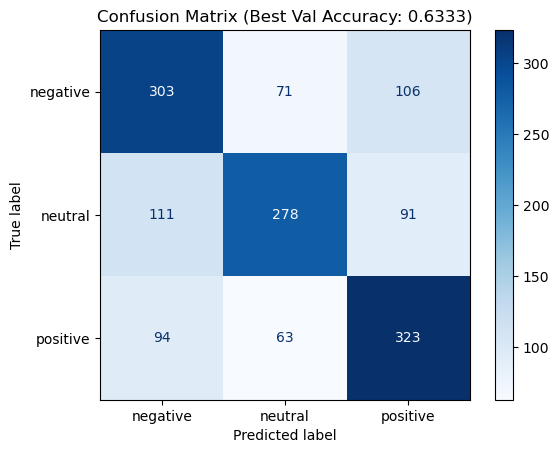

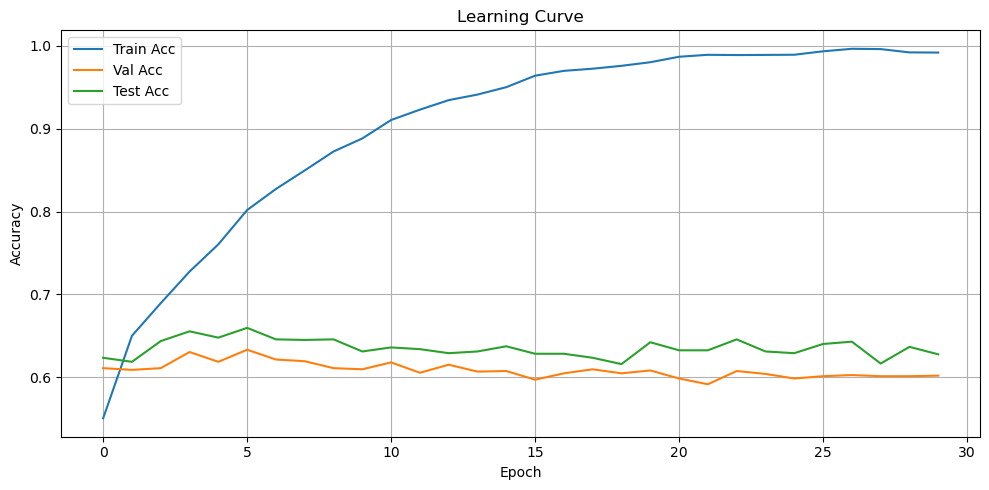

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()
def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load & Preprocess Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)

# ------------------- Build Vocab -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Prepare Dataset -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.lengths = [min(len(t), 150) for t in texts]
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx], self.lengths[idx]

def collate_fn(batch):
    texts, labels, lengths = zip(*batch)
    return torch.stack(texts), torch.tensor(labels, dtype=torch.long), torch.tensor(lengths, dtype=torch.long)

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=128, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=128, collate_fn=collate_fn)

# ------------------- GRU Model (No Dropout) -------------------
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_dim, output_dim, n_layers=3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = True
        self.gru = nn.GRU(embed_size, hidden_dim, n_layers, batch_first=True, bidirectional=bidirectional)
        self.norm = nn.LayerNorm(hidden_dim * 2 if bidirectional else hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, output_dim)

    def forward(self, x, lengths):
        x = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        if self.gru.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        hidden = self.norm(hidden)
        return self.fc(hidden)

# ------------------- Train -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = GRUClassifier(len(vocab)+1, 300, hidden_dim=512, output_dim=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.8)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0
        for x, y, l in train_loader:
            x, y, l = x.to(device), y.to(device), l.to(device)
            optimizer.zero_grad()
            output = model(x, l)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            pred = torch.argmax(output, dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for x, y, l in val_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y, l in test_loader:
                x, y, l = x.to(device), y.to(device), l.to(device)
                output = model(x, l)
                pred = torch.argmax(output, dim=1)
                test_correct += (pred == y).sum().item()
                test_total += y.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)
        scheduler.step()

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)
